# BNPL Project — Analysis 4
## Propensity Score Matching (Caliper + Covariate Balance)

In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
z = zipfile.ZipFile('../data/raw/public2024.csv.zip')
df = pd.read_csv(z.open('public2024.csv'), low_memory=False)

df['bnpl_use'] = df['BNPL1'].apply(lambda x: 1 if x == 'Yes' else 0)
df['age_cat'] = df['ppagecat']
df['income_cat'] = df['inc_4cat_50k']
df['race_cat'] = df['race_5cat']
df['educ_cat'] = df['educ_4cat']

# Re-run a simplified PCA here to get vulnerability_score
df['fragile_EF1'] = df['EF1'].apply(lambda x: 1 if x == 'No' else 0)
df['fragile_okay'] = df['atleast_okay'].apply(lambda x: 1 if x == 'No' else 0)
df['fragile_E2'] = df['E2'].apply(lambda x: 1 if x == 'Yes' else 0)
df['fragile_K0'] = df['K0'].apply(lambda x: 1 if x == 'Yes' else 0)

fragility_cols = ['fragile_EF1', 'fragile_okay', 'fragile_E2', 'fragile_K0']
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sub = df.dropna(subset=fragility_cols + ['weight'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sub[fragility_cols])
pca = PCA(n_components=1)
sub['vulnerability_score'] = pca.fit_transform(X_scaled)
if sub[['vulnerability_score', 'fragile_EF1']].corr().iloc[0,1] < 0:
    sub['vulnerability_score'] *= -1

df = df.merge(sub[['vulnerability_score']], left_index=True, right_index=True, how='left')
demographics = ['age_cat', 'income_cat', 'race_cat', 'educ_cat']
df_reg = df.dropna(subset=['bnpl_use', 'vulnerability_score', 'weight'] + demographics).copy()


Loading data...


### Propensity Score Calculation & Caliper Matching

In [2]:
# Median split to define 'Fragile' vs 'Non-Fragile'
median_vuln = df_reg['vulnerability_score'].median()
df_reg['is_fragile'] = (df_reg['vulnerability_score'] > median_vuln).astype(int)

# Logistic regression for propensity score based on demographics, adjusting for survey weights
formula_psm = 'is_fragile ~ age_cat + income_cat + race_cat + educ_cat'
# Generalized Linear Model with Binomial family and survey weights
glm_binom = sm.families.Binomial()
logit_model = smf.glm(formula=formula_psm, data=df_reg, family=glm_binom, freq_weights=df_reg['weight']).fit()
df_reg['propensity_score'] = logit_model.predict(df_reg)
df_reg['logit_ps'] = np.log(df_reg['propensity_score'] / (1 - df_reg['propensity_score']))

fragile_df = df_reg[df_reg['is_fragile'] == 1].reset_index(drop=True)
control_df = df_reg[df_reg['is_fragile'] == 0].reset_index(drop=True)

# Caliper Matching (0.2 Standard Deviations of logit propensity score)
caliper = 0.2 * df_reg['logit_ps'].std()
print(f"Using caliper: {caliper:.4f} logit units")

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control_df[['logit_ps']])
distances, indices = nn.kneighbors(fragile_df[['logit_ps']])

# Filter by caliper
valid_matches = distances.flatten() <= caliper
matched_fragile = fragile_df[valid_matches].reset_index(drop=True)
matched_control = control_df.iloc[indices.flatten()[valid_matches]].reset_index(drop=True)

print(f"Matched {len(matched_fragile)} out of {len(fragile_df)} fragile individuals ({(len(matched_fragile)/len(fragile_df)):.1%})")


Using caliper: 0.2552 logit units
Matched 5374 out of 5374 fragile individuals (100.0%)


### Covariate Balance (Standardized Mean Differences)


Standardized Mean Differences (SMD):
                              Unmatched   Matched
age_cat_25-34                  0.145590  0.000979
age_cat_35-44                  0.113094  0.002381
age_cat_45-54                  0.074582  0.009196
age_cat_55-64                  0.069066  0.001973
age_cat_65-74                  0.242802  0.000555
age_cat_75+                    0.259227  0.008544
income_cat_$25,000–$49,999     0.334936  0.006620
income_cat_$50,000–$99,999     0.018528  0.002933
income_cat_Less than $25,000   0.675538  0.006414
race_cat_Black                 0.202403  0.018161


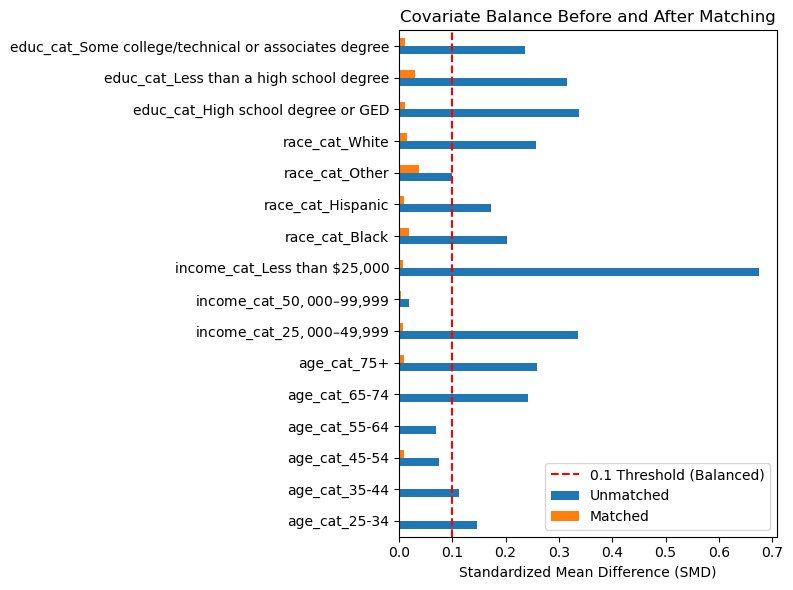


--- Propensity Score Matching Results (Caliper Matching) ---
Fragile BNPL Use Rate (Matched): 0.2071
Non-Fragile BNPL Use Rate (Matched Controls): 0.1615
Paired T-test p-value (Matched groups): 4.0618e-10


In [3]:
# Calculate SMD for age_cat[T.25-34] as an example to check balance
def get_dummies(df, cols):
    return pd.get_dummies(df[cols], drop_first=True)

X_fragile = get_dummies(fragile_df, demographics)
X_control = get_dummies(control_df, demographics)
X_matched_fragile = get_dummies(matched_fragile, demographics)
X_matched_control = get_dummies(matched_control, demographics)

def calc_smd(df1, df2):
    mean_diff = df1.mean() - df2.mean()
    pooled_sd = np.sqrt((df1.var() + df2.var()) / 2)
    return (mean_diff / pooled_sd).abs()

smd_unmatched = calc_smd(X_fragile, X_control)
smd_matched = calc_smd(X_matched_fragile, X_matched_control)

smd_df = pd.DataFrame({
    'Unmatched': smd_unmatched,
    'Matched': smd_matched
})

print("\nStandardized Mean Differences (SMD):")
print(smd_df.head(10))

# Plot SMD
smd_df.plot(kind='barh', figsize=(8, 6))
plt.axvline(x=0.1, color='r', linestyle='--', label='0.1 Threshold (Balanced)')
plt.title('Covariate Balance Before and After Matching')
plt.xlabel('Standardized Mean Difference (SMD)')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/psm_covariate_balance.png')
plt.show()

# Final T-test
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(matched_fragile['bnpl_use'], matched_control['bnpl_use'])
print(f"\n--- Propensity Score Matching Results (Caliper Matching) ---")
print(f"Fragile BNPL Use Rate (Matched): {matched_fragile['bnpl_use'].mean():.4f}")
print(f"Non-Fragile BNPL Use Rate (Matched Controls): {matched_control['bnpl_use'].mean():.4f}")
print(f"Paired T-test p-value (Matched groups): {p_val:.4e}")
